# Q5 — Are some platforms systematically optimistic/pessimistic?

**How is the baseline set?** A naive bias = *rating − mean of all platforms* is biased
toward zero because the platform is part of its own baseline. We therefore report several
established measures and compare them:

- **Raw mean rating** per platform (uncontrolled).
- **Leave-one-out (LOO) deviation** — each rating minus the consensus of the *other*
  platforms only. This is the cleanest signed-bias measure (no self-inclusion).
- **Pairwise signed differences** (A − B over venues on both) — model-free and symmetric.

(A two-way fixed-effects model *rating ~ restaurant + platform* would give an equivalent
platform effect; with at most three platforms the LOO/pairwise measures capture the same
signal without the extra machinery.)

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
rows = run(queries.q5_platform_rows())
cols = {"google": "google_rating_5", "tripadvisor": "tripadvisor_rating_5", "thefork": "thefork_rating_5"}

bias = []
for p, c in cols.items():
    others = [oc for op, oc in cols.items() if op != p]
    present = rows[rows[c].notna()]
    consensus_loo = present[others].mean(axis=1)            # mean of the OTHER platforms
    bias.append({
        "platform": p,
        "rated_venues": int(present[c].notna().sum()),
        "mean_rating": round(present[c].mean(), 3),
        "loo_deviation": round((present[c] - consensus_loo).mean(), 3),
        "dev_from_consensus": round((present[c] - present["rating_avg_5"]).mean(), 3),
    })
q5_bias = publish(pd.DataFrame(bias), "q5_platform_bias",
                  "Q5 — Platform bias: raw mean, leave-one-out deviation, deviation from consensus.")
q5_bias

,platform,rated_venues,mean_rating,loo_deviation,dev_from_consensus
0,google,4070,4.296,0.308,0.157
1,tripadvisor,3913,3.939,-0.362,-0.191
2,thefork,886,4.437,0.180,0.122


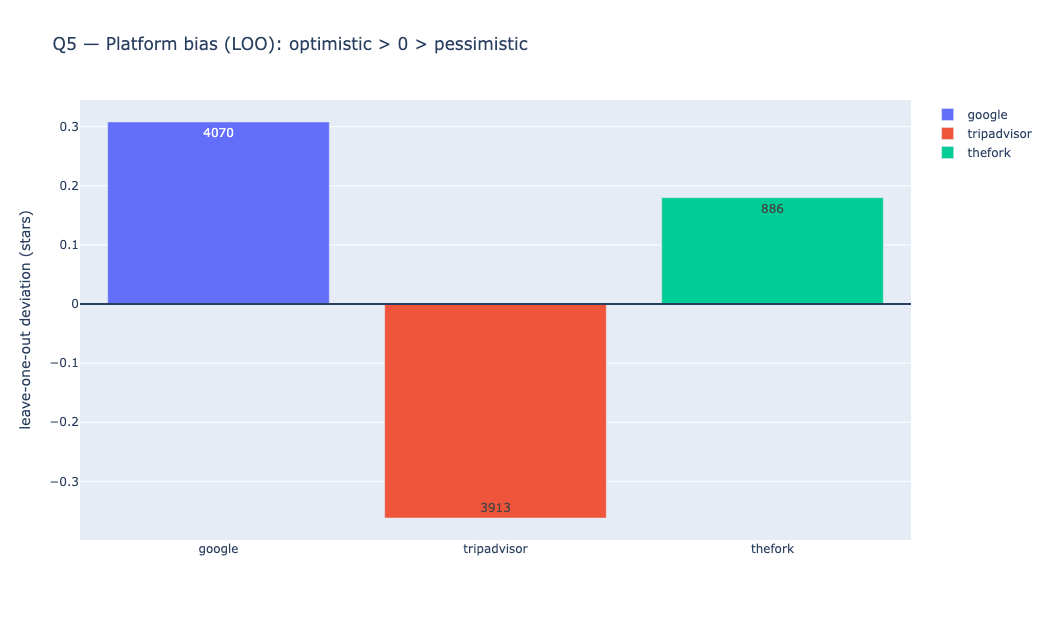

In [3]:
fig = px.bar(q5_bias, x="platform", y="loo_deviation", color="platform", text="rated_venues",
             labels={"loo_deviation": "leave-one-out deviation (stars)", "platform": ""},
             title="Q5 — Platform bias (LOO): optimistic > 0 > pessimistic")
fig.add_hline(y=0)
fig.show()

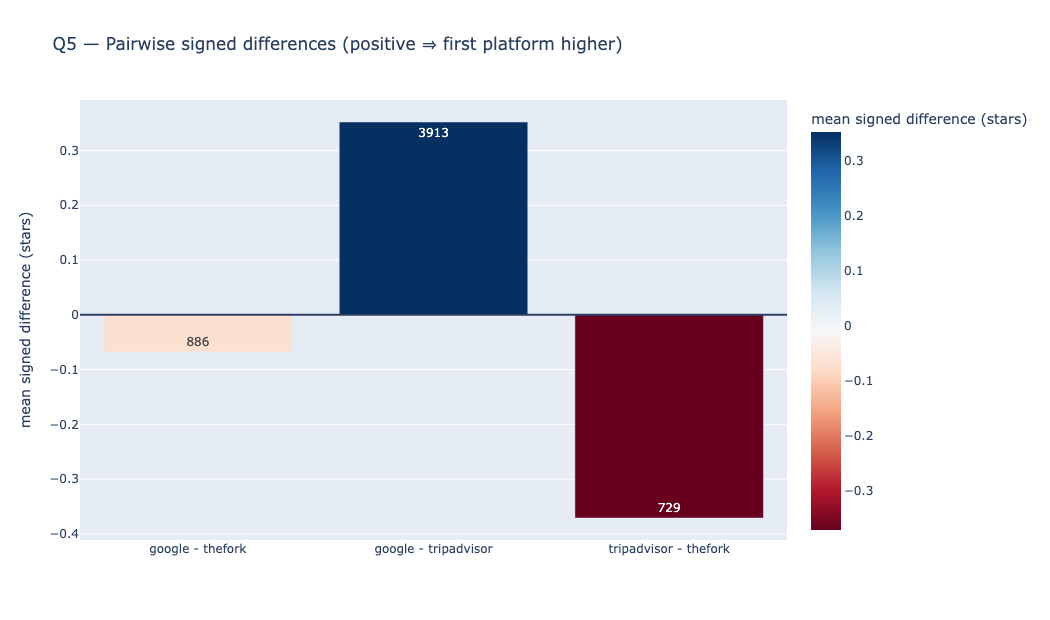

,pair,venues,mean_signed_diff
0,google - thefork,886,-0.068
1,google - tripadvisor,3913,0.352
2,tripadvisor - thefork,729,-0.371


In [4]:
q5_pair = publish(run(queries.q5_pairwise_differences()), "q5_pairwise_differences",
                  "Q5 — Mean signed rating difference per ordered platform pair (A − B).")
fig = px.bar(q5_pair, x="pair", y="mean_signed_diff", color="mean_signed_diff",
             color_continuous_scale="RdBu", text="venues",
             labels={"mean_signed_diff": "mean signed difference (stars)", "pair": ""},
             title="Q5 — Pairwise signed differences (positive ⇒ first platform higher)")
fig.add_hline(y=0)
fig.show()
q5_pair

**Answer (Q5):** All three measures agree on the ordering. **Tripadvisor is
systematically the most pessimistic** (negative LOO deviation; Google − Tripadvisor and
TheFork − Tripadvisor both positive), while **TheFork rates highest** and Google sits in
between. The agreement of the raw, LOO and pairwise measures makes the direction robust to
how the baseline is defined.